# SDG 3 Indicator Text Classification
## Notebook 4 — Results, Evaluation & Final Predictions

In [ ]:
# 0. Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn joblib scipy -q

import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, scipy.sparse as sp
warnings.filterwarnings('ignore')

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    multilabel_confusion_matrix, classification_report
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
PROJECT_FOLDER = '/content/drive/MyDrive/SDG/'
os.makedirs(PROJECT_FOLDER + 'outputs', exist_ok=True)
os.makedirs(PROJECT_FOLDER + 'visualizations', exist_ok=True)
print(" Setup complete.")


Mounted at /content/drive
 Setup complete.


## Load All Artifacts

In [ ]:
# 1. Load everything from previous notebooks
label_columns = np.load(PROJECT_FOLDER + 'features/indicator_names.npy', allow_pickle=True)
y_full        = np.load(PROJECT_FOLDER + 'features/y_labels.npy')
X_full        = sp.load_npz(PROJECT_FOLDER + 'features/X_tfidf_bigram.npz')
best_model    = joblib.load(PROJECT_FOLDER + 'best_model_svm.pkl')
all_results   = pd.read_csv(PROJECT_FOLDER + 'all_experiments_final.csv')
train_df      = pd.read_csv(PROJECT_FOLDER + 'train_processed.csv')
text_col      = 'text_clean_standard' if 'text_clean_standard' in train_df.columns else 'processed_text'

# Load test data
X_test   = sp.load_npz(PROJECT_FOLDER + 'features/X_test_tfidf_bigram.npz')
test_ids = pd.read_csv(PROJECT_FOLDER + 'test_ids.csv')

# Load best threshold from Notebook 3
if os.path.exists(PROJECT_FOLDER + 'best_threshold.json'):
    with open(PROJECT_FOLDER + 'best_threshold.json') as fh:
        BEST_THRESH = json.load(fh)['best_threshold']
else:
    BEST_THRESH = 0.30  # sensible default
    print("⚠ best_threshold.json not found — using default 0.30")

print(f"Labels         : {len(label_columns)}")
print(f"Feature matrix : {X_full.shape}")
print(f"Label matrix   : {y_full.shape}")
print(f"Test matrix    : {X_test.shape}")
print(f"Best threshold : {BEST_THRESH}")

# Canonical 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)
print(f"\nTrain: {X_train.shape[0]}  |  Validation: {X_val.shape[0]}")


Labels         : 27
Feature matrix : (2995, 10000)
Label matrix   : (2995, 27)
Test matrix    : (998, 10000)
Best threshold : 0.40000000000000013

Train: 2396  |  Validation: 599


## Complete Experiment Comparison Table

In [ ]:
# Clean and sort results table
for col in ['Hamming Loss', 'F1-micro', 'F1-macro', 'Precision', 'Recall']:
    if col in all_results.columns:
        all_results[col] = pd.to_numeric(all_results[col], errors='coerce')

all_sorted = all_results.sort_values('Hamming Loss').reset_index(drop=True)
all_sorted.index += 1   # 1-indexed

print("=" * 80)
print("COMPLETE EXPERIMENT RESULTS (All 12 Experiments — Sorted by Hamming Loss)")
print("=" * 80)
display(all_sorted)

best_row = all_sorted.iloc[0]
print(f"\n Best experiment  : {best_row['Experiment']}")
print(f"  Hamming Loss     : {best_row['Hamming Loss']:.4f}")
print(f"  F1-micro         : {best_row['F1-micro']}")


COMPLETE EXPERIMENT RESULTS (All 12 Experiments — Sorted by Hamming Loss)


,Experiment,Hamming Loss,F1-micro,F1-macro,Precision,Recall
1,Exp 12: Threshold Tuning (best),0.0434,0.6490,0.5657,NaN,NaN
2,Exp 12: Default t=0.50,0.0445,0.6116,NaN,NaN,NaN
3,Exp 3: Linear SVM,0.0458,0.6023,0.5054,0.8084,0.4799
4,Exp 4: Tuned LR,0.0480,0.5698,0.4449,0.8094,0.4397
5,Exp 2: Random Forest,0.0513,0.5063,0.3568,0.8333,0.3636
6,Exp 7: ngram comparison,0.0530,NaN,NaN,NaN,NaN
7,Exp 6: max_features sweep,0.0532,NaN,NaN,NaN,NaN
8,Exp 9: CountVectorizer,0.0544,0.5749,0.4930,0.6604,0.5090
9,Exp 10: Stemming,0.0550,0.4265,0.2407,0.8642,0.2831
10,Exp 9: TF-IDF baseline,0.0554,0.4219,0.2379,0.8583,0.2797



 Best experiment  : Exp 12: Threshold Tuning (best)
  Hamming Loss     : 0.0434
  F1-micro         : 0.649


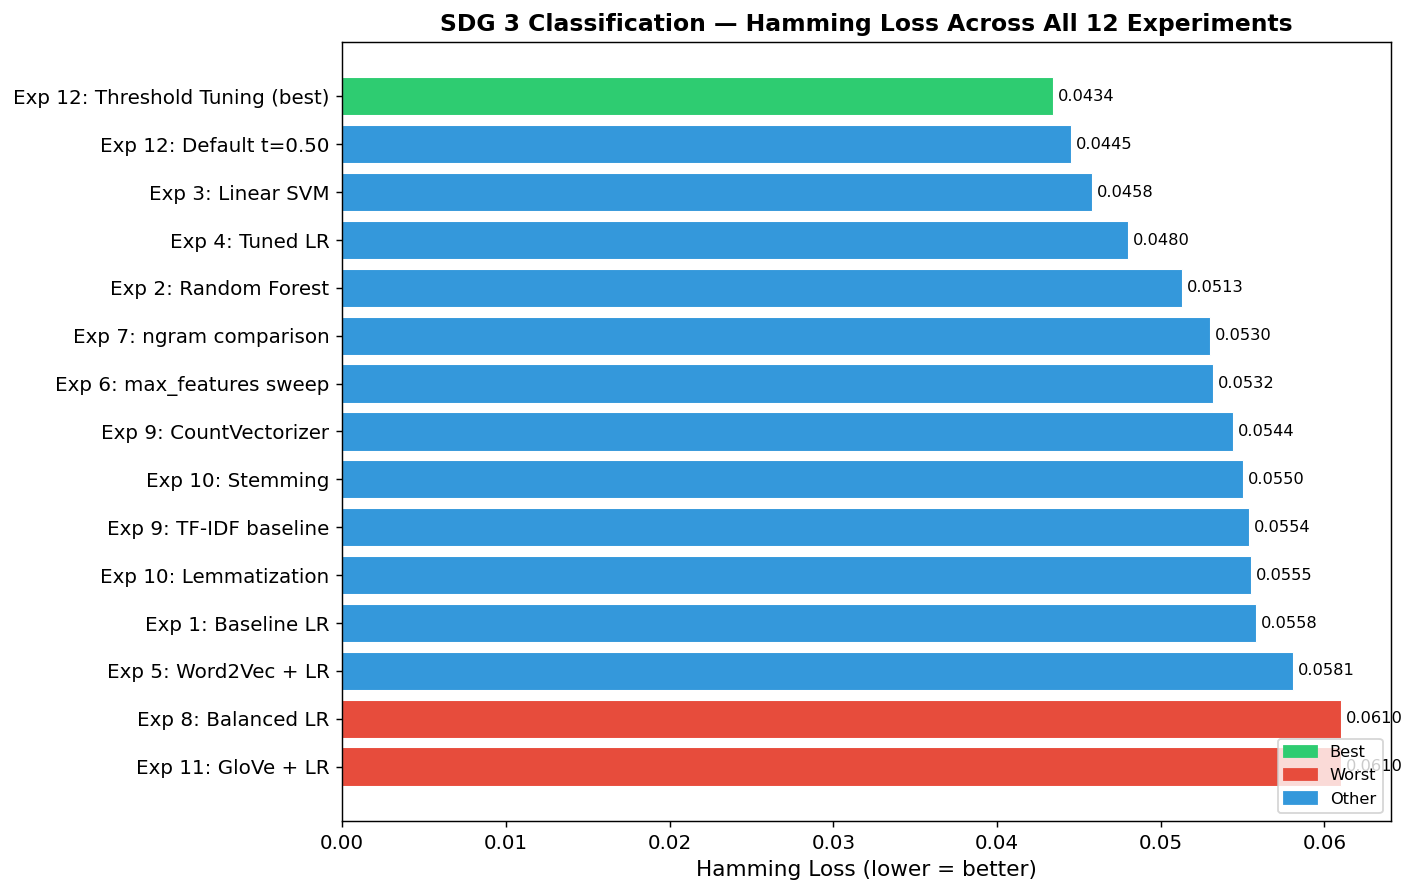

Saved: all_experiments_hamming_loss.png


In [ ]:
# Horizontal bar chart — all experiments
fig, ax = plt.subplots(figsize=(11, 7))
exp_labels = all_sorted['Experiment'].tolist()
hl_vals    = all_sorted['Hamming Loss'].values

colors = ['#2ecc71' if i == 0 else
          '#e74c3c' if v == hl_vals.max() else '#3498db'
          for i, v in enumerate(hl_vals)]

bars = ax.barh(exp_labels, hl_vals, color=colors, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, hl_vals):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Hamming Loss (lower = better)', fontsize=12)
ax.set_title('SDG 3 Classification — Hamming Loss Across All 12 Experiments',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Best'),
    mpatches.Patch(color='#e74c3c', label='Worst'),
    mpatches.Patch(color='#3498db', label='Other'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/all_experiments_hamming_loss.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_experiments_hamming_loss.png")


## Best Model — Detailed Validation Metrics

In [ ]:
y_pred_val = best_model.predict(X_val)

hl   = hamming_loss(y_val, y_pred_val)
f1m  = f1_score(y_val, y_pred_val, average='micro',    zero_division=0)
f1M  = f1_score(y_val, y_pred_val, average='macro',    zero_division=0)
f1s  = f1_score(y_val, y_pred_val, average='samples',  zero_division=0)
prec = precision_score(y_val, y_pred_val, average='micro', zero_division=0)
rec  = recall_score(y_val, y_pred_val,    average='micro', zero_division=0)
exact = np.mean(np.all(y_val == y_pred_val, axis=1))

print("=" * 65)
print("BEST MODEL — Validation Set Metrics (Linear SVM + TF-IDF Bigram)")
print("=" * 65)
print(f"  Hamming Loss         : {hl:.4f}   ← primary metric")
print(f"  F1-micro             : {f1m:.4f}")
print(f"  F1-macro             : {f1M:.4f}")
print(f"  F1-samples           : {f1s:.4f}")
print(f"  Precision (micro)    : {prec:.4f}")
print(f"  Recall    (micro)    : {rec:.4f}")
print(f"  Exact Match Ratio    : {exact:.4f}")
print("=" * 65)

print("\n Full per-label classification report ")
print(classification_report(y_val, y_pred_val,
                             target_names=label_columns, zero_division=0))


BEST MODEL — Validation Set Metrics (Linear SVM + TF-IDF Bigram)
  Hamming Loss         : 0.0458   ← primary metric
  F1-micro             : 0.6023
  F1-macro             : 0.5054
  F1-samples           : 0.5799
  Precision (micro)    : 0.8084
  Recall    (micro)    : 0.4799
  Exact Match Ratio    : 0.3589

 Full per-label classification report 
              precision    recall  f1-score   support

       3.1.1       0.82      0.47      0.60        30
       3.1.2       0.33      0.06      0.10        18
       3.2.1       0.78      0.40      0.53        45
       3.2.2       0.60      0.16      0.25        19
       3.3.1       0.97      0.72      0.82        78
       3.3.2       0.95      0.40      0.57        47
       3.3.3       0.96      0.58      0.72        45
       3.3.4       1.00      0.24      0.38        17
       3.3.5       0.71      0.44      0.55        34
       3.4.1       0.94      0.65      0.76        93
       3.4.2       0.75      0.27      0.40        11
   

## Per-Label F1 Analysis

Per-Label Performance:


,Indicator,F1,Precision,Recall,Support
0,3.3.1,0.823529,0.965517,0.717949,78
1,3.4.1,0.764331,0.937500,0.645161,93
2,3.b.2,0.732057,0.753695,0.711628,215
3,3.7.2,0.730769,0.950000,0.593750,32
4,3.3.3,0.722222,0.962963,0.577778,45
5,3.7.1,0.678571,0.904762,0.542857,35
6,3.5.1,0.615385,0.800000,0.500000,16
7,3.1.1,0.595745,0.823529,0.466667,30
8,3.d.1,0.580645,0.900000,0.428571,42
9,3.3.2,0.567164,0.950000,0.404255,47


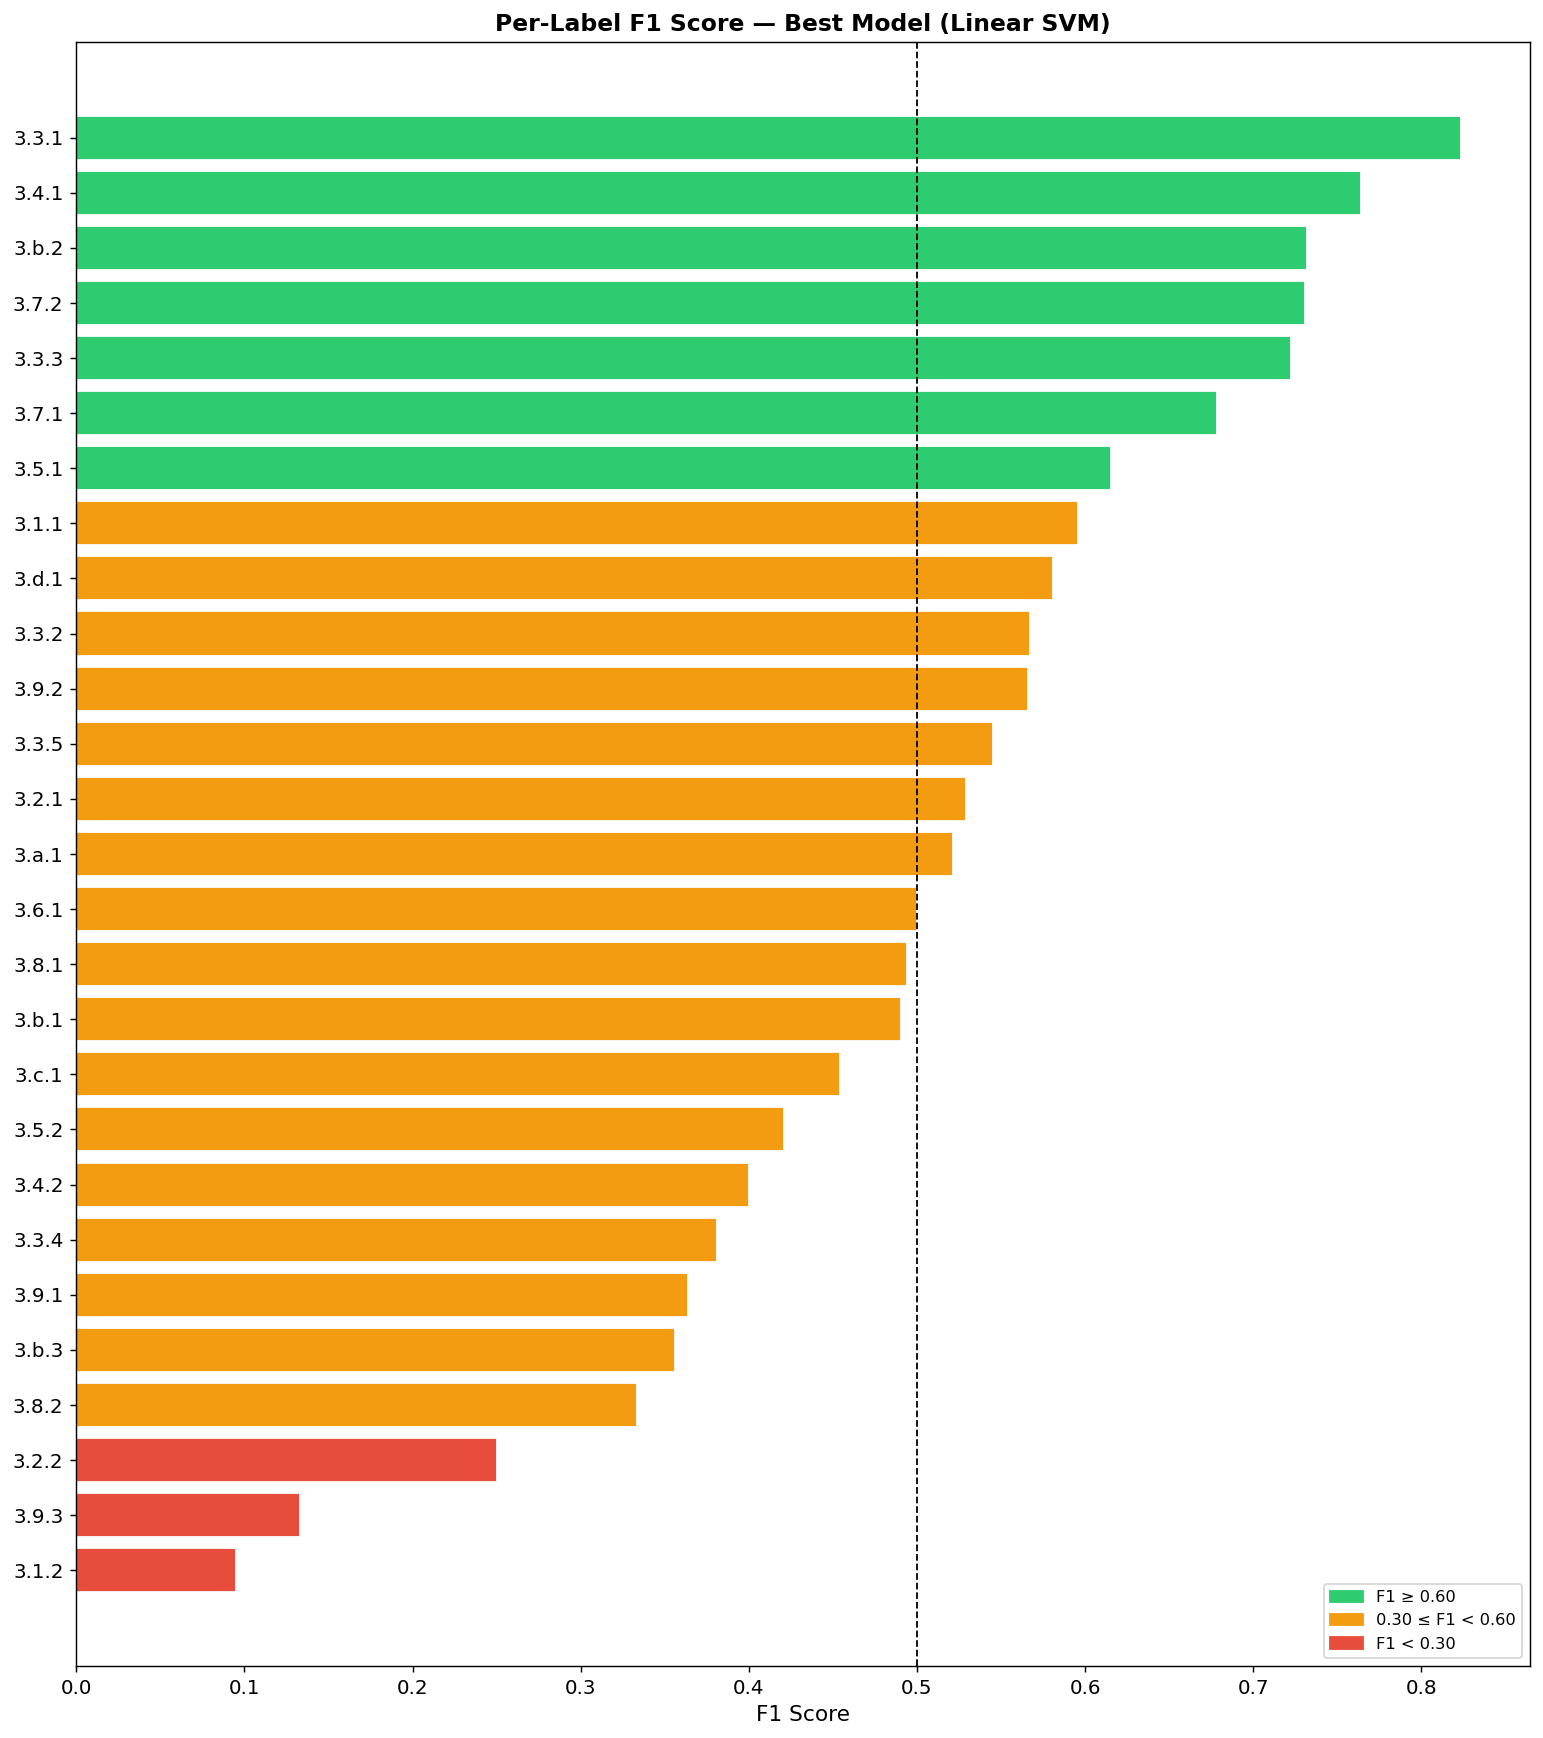

Saved: per_label_f1.png


In [ ]:
f1_per    = f1_score(y_val, y_pred_val, average=None, zero_division=0)
prec_per  = precision_score(y_val, y_pred_val, average=None, zero_division=0)
rec_per   = recall_score(y_val, y_pred_val, average=None, zero_division=0)
support   = y_val.sum(axis=0).astype(int)

per_label = pd.DataFrame({
    'Indicator': label_columns,
    'F1':        f1_per,
    'Precision': prec_per,
    'Recall':    rec_per,
    'Support':   support
}).sort_values('F1', ascending=False).reset_index(drop=True)

print("Per-Label Performance:")
display(per_label)

# Bar chart
fig, ax = plt.subplots(figsize=(12, max(5, len(label_columns)*0.5)))
palette = ['#2ecc71' if f >= 0.6 else '#f39c12' if f >= 0.3 else '#e74c3c'
           for f in per_label['F1']]
ax.barh(per_label['Indicator'], per_label['F1'], color=palette, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.0, label='F1 = 0.50')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Label F1 Score — Best Model (Linear SVM)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='F1 ≥ 0.60'),
    mpatches.Patch(color='#f39c12', label='0.30 ≤ F1 < 0.60'),
    mpatches.Patch(color='#e74c3c', label='F1 < 0.30'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/per_label_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_label_f1.png")


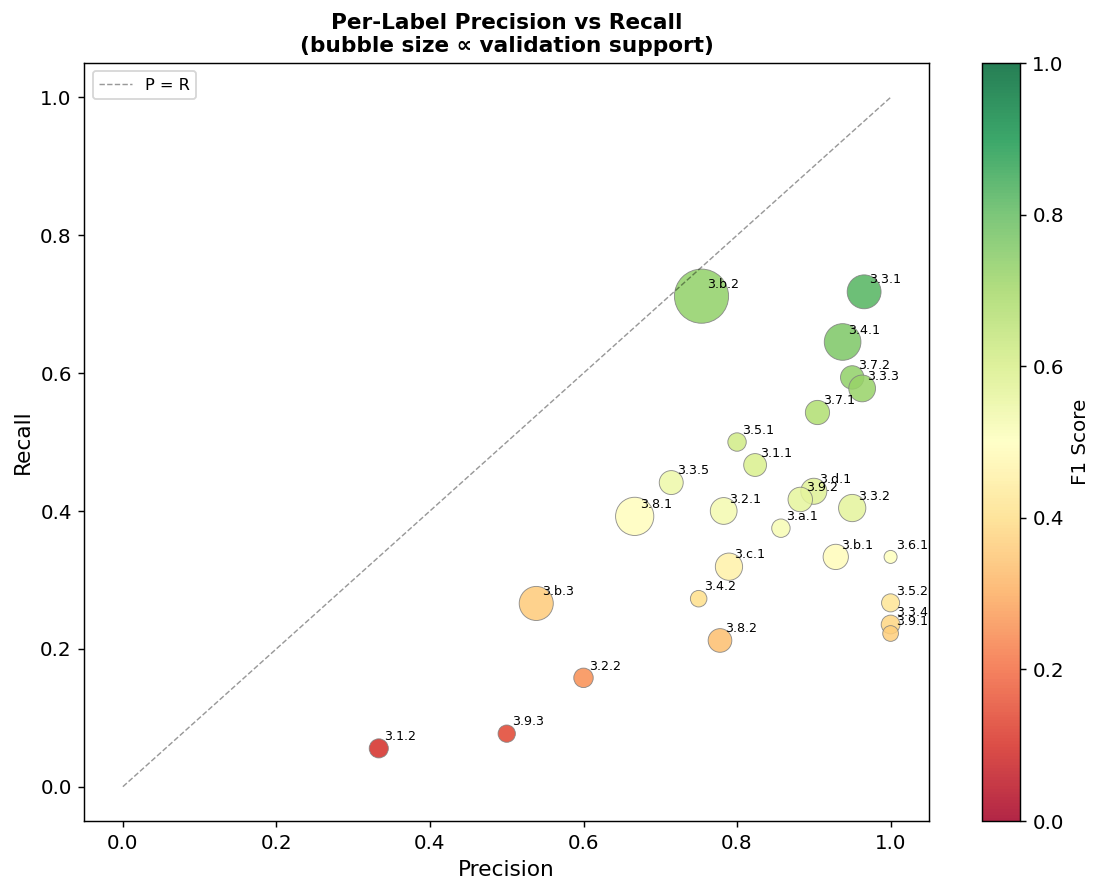

Saved: precision_recall_scatter.png


In [ ]:
# Precision vs Recall scatter (per label), bubble size = support
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    per_label['Precision'], per_label['Recall'],
    s=per_label['Support'] * 4 + 40,
    c=per_label['F1'], cmap='RdYlGn', vmin=0, vmax=1,
    edgecolors='grey', linewidths=0.5, alpha=0.85
)
for _, row in per_label.iterrows():
    ax.annotate(row['Indicator'], (row['Precision'], row['Recall']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
plt.colorbar(scatter, ax=ax, label='F1 Score')
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4, label='P = R')
ax.set_xlabel('Precision', fontsize=12); ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Per-Label Precision vs Recall\n(bubble size ∝ validation support)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: precision_recall_scatter.png")


## Multi-Label Confusion Matrices

Multi-label confusion matrix summary:


,Label,TP,FP,FN,TN
0,3.1.1,14,3,16,566
1,3.1.2,1,2,17,579
2,3.2.1,18,5,27,549
3,3.2.2,3,2,16,578
4,3.3.1,56,2,22,519
5,3.3.2,19,1,28,551
6,3.3.3,26,1,19,553
7,3.3.4,4,0,13,582
8,3.3.5,15,6,19,559
9,3.4.1,60,4,33,502


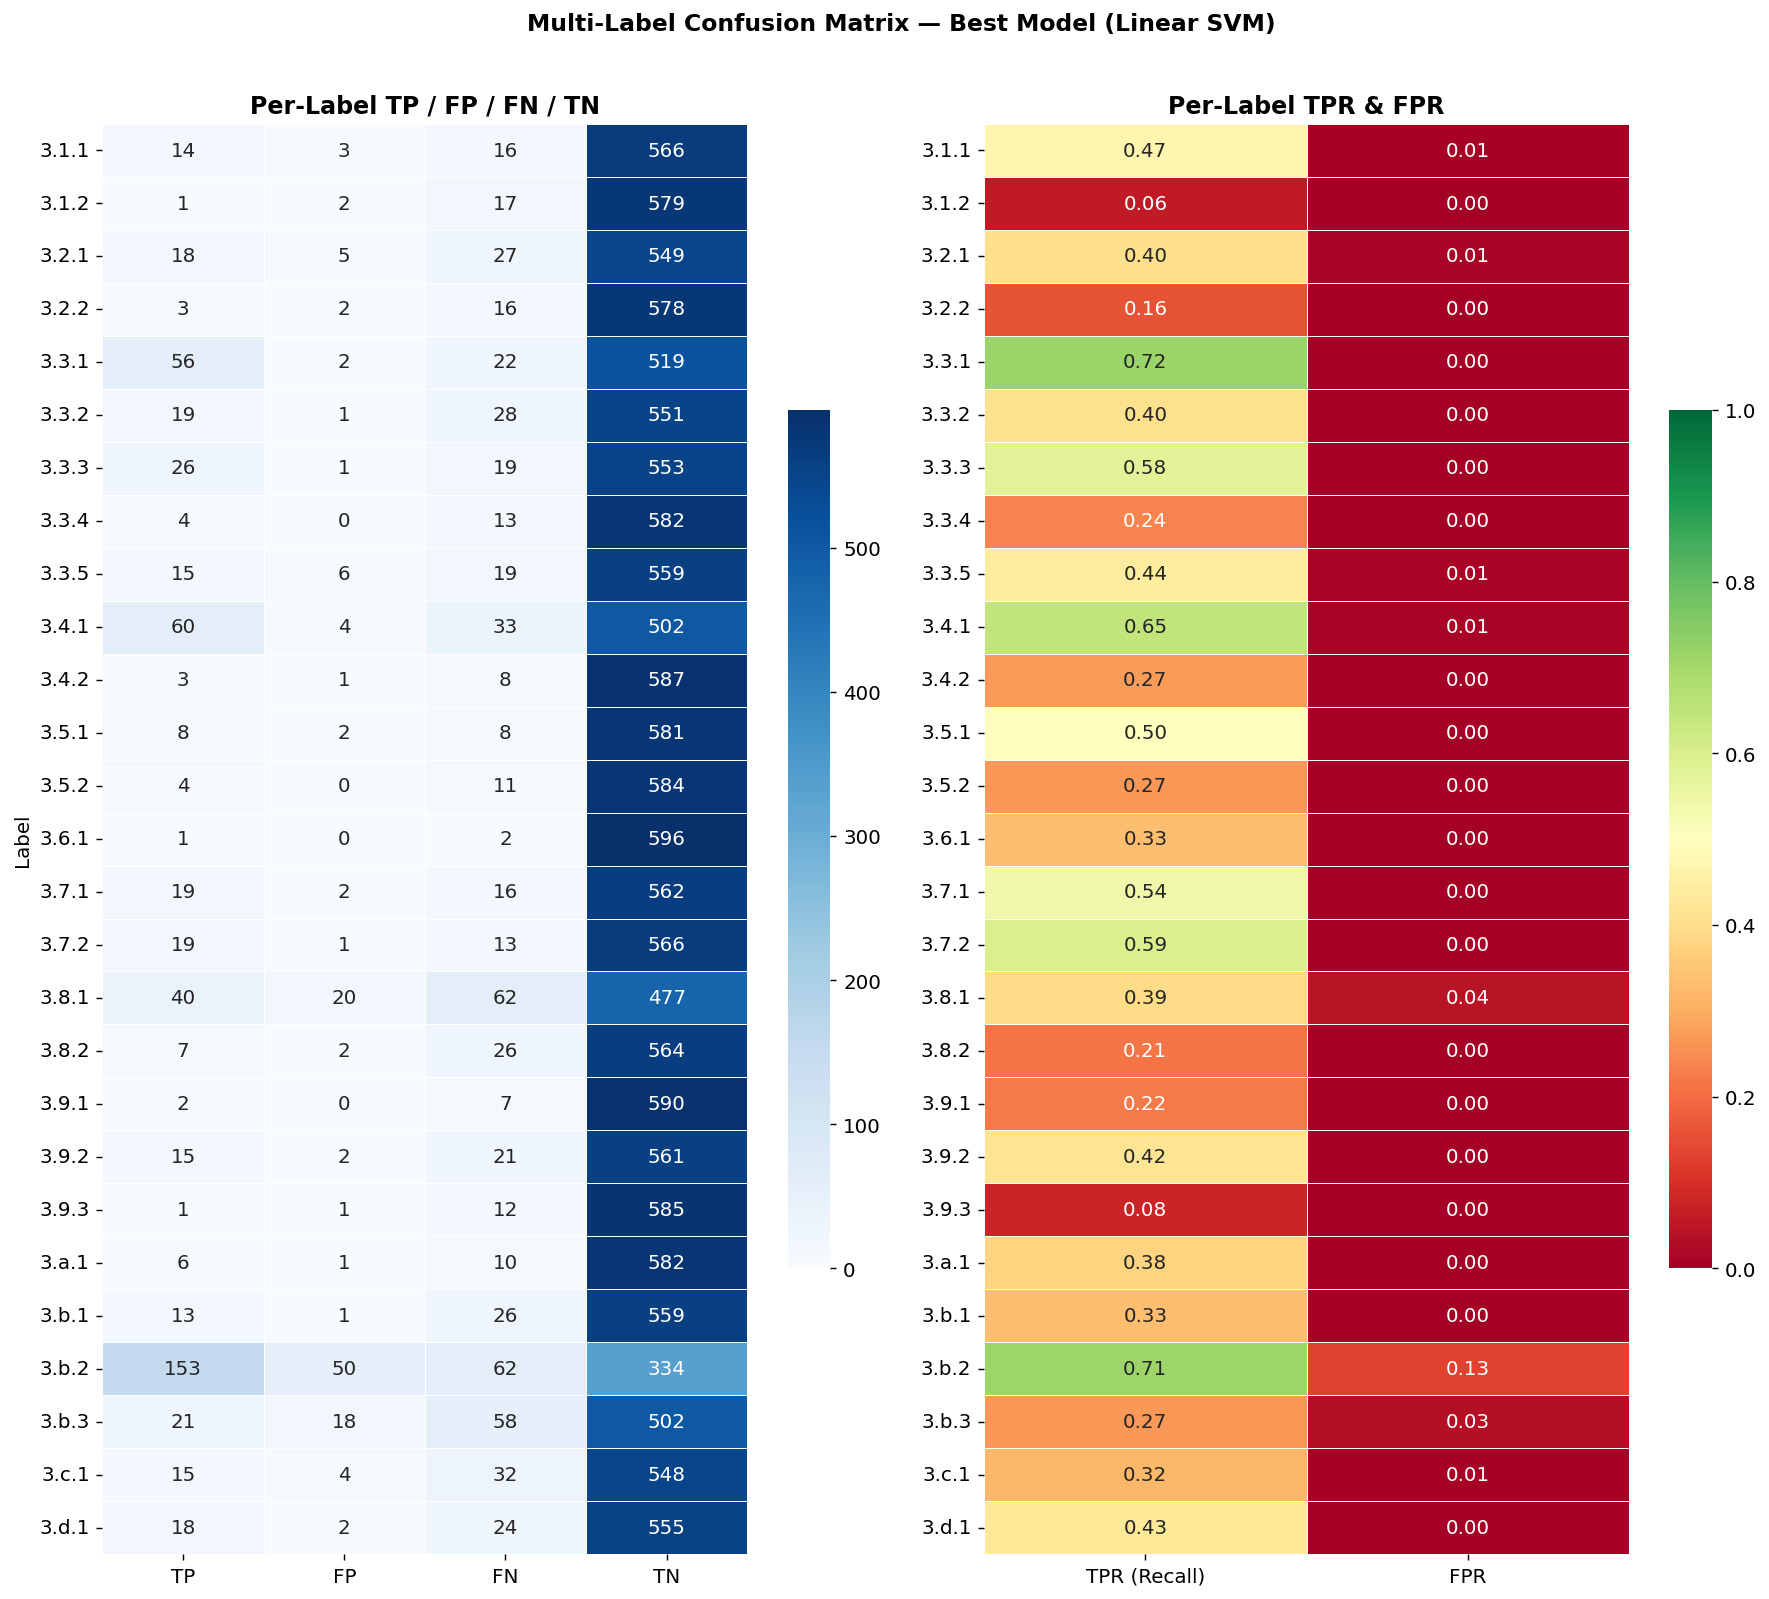

Saved: confusion_matrix_best_model.png


In [ ]:
mcm = multilabel_confusion_matrix(y_val, y_pred_val)
tn  = mcm[:, 0, 0]; fp = mcm[:, 0, 1]
fn  = mcm[:, 1, 0]; tp = mcm[:, 1, 1]

cm_df = pd.DataFrame({'Label': label_columns,
                       'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})
print("Multi-label confusion matrix summary:")
display(cm_df)

# Aggregate heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(label_columns)*0.45)))
hm = cm_df.set_index('Label')[['TP','FP','FN','TN']]
sns.heatmap(hm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, cbar_kws={'shrink':0.6})
axes[0].set_title('Per-Label TP / FP / FN / TN', fontweight='bold')

tpr = np.where((tp+fn) > 0, tp/(tp+fn), 0)
fpr = np.where((fp+tn) > 0, fp/(fp+tn), 0)
rates = pd.DataFrame({'TPR (Recall)': tpr, 'FPR': fpr}, index=label_columns)
sns.heatmap(rates, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'shrink':0.6})
axes[1].set_title('Per-Label TPR & FPR', fontweight='bold')
plt.suptitle('Multi-Label Confusion Matrix — Best Model (Linear SVM)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/confusion_matrix_best_model.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_best_model.png")


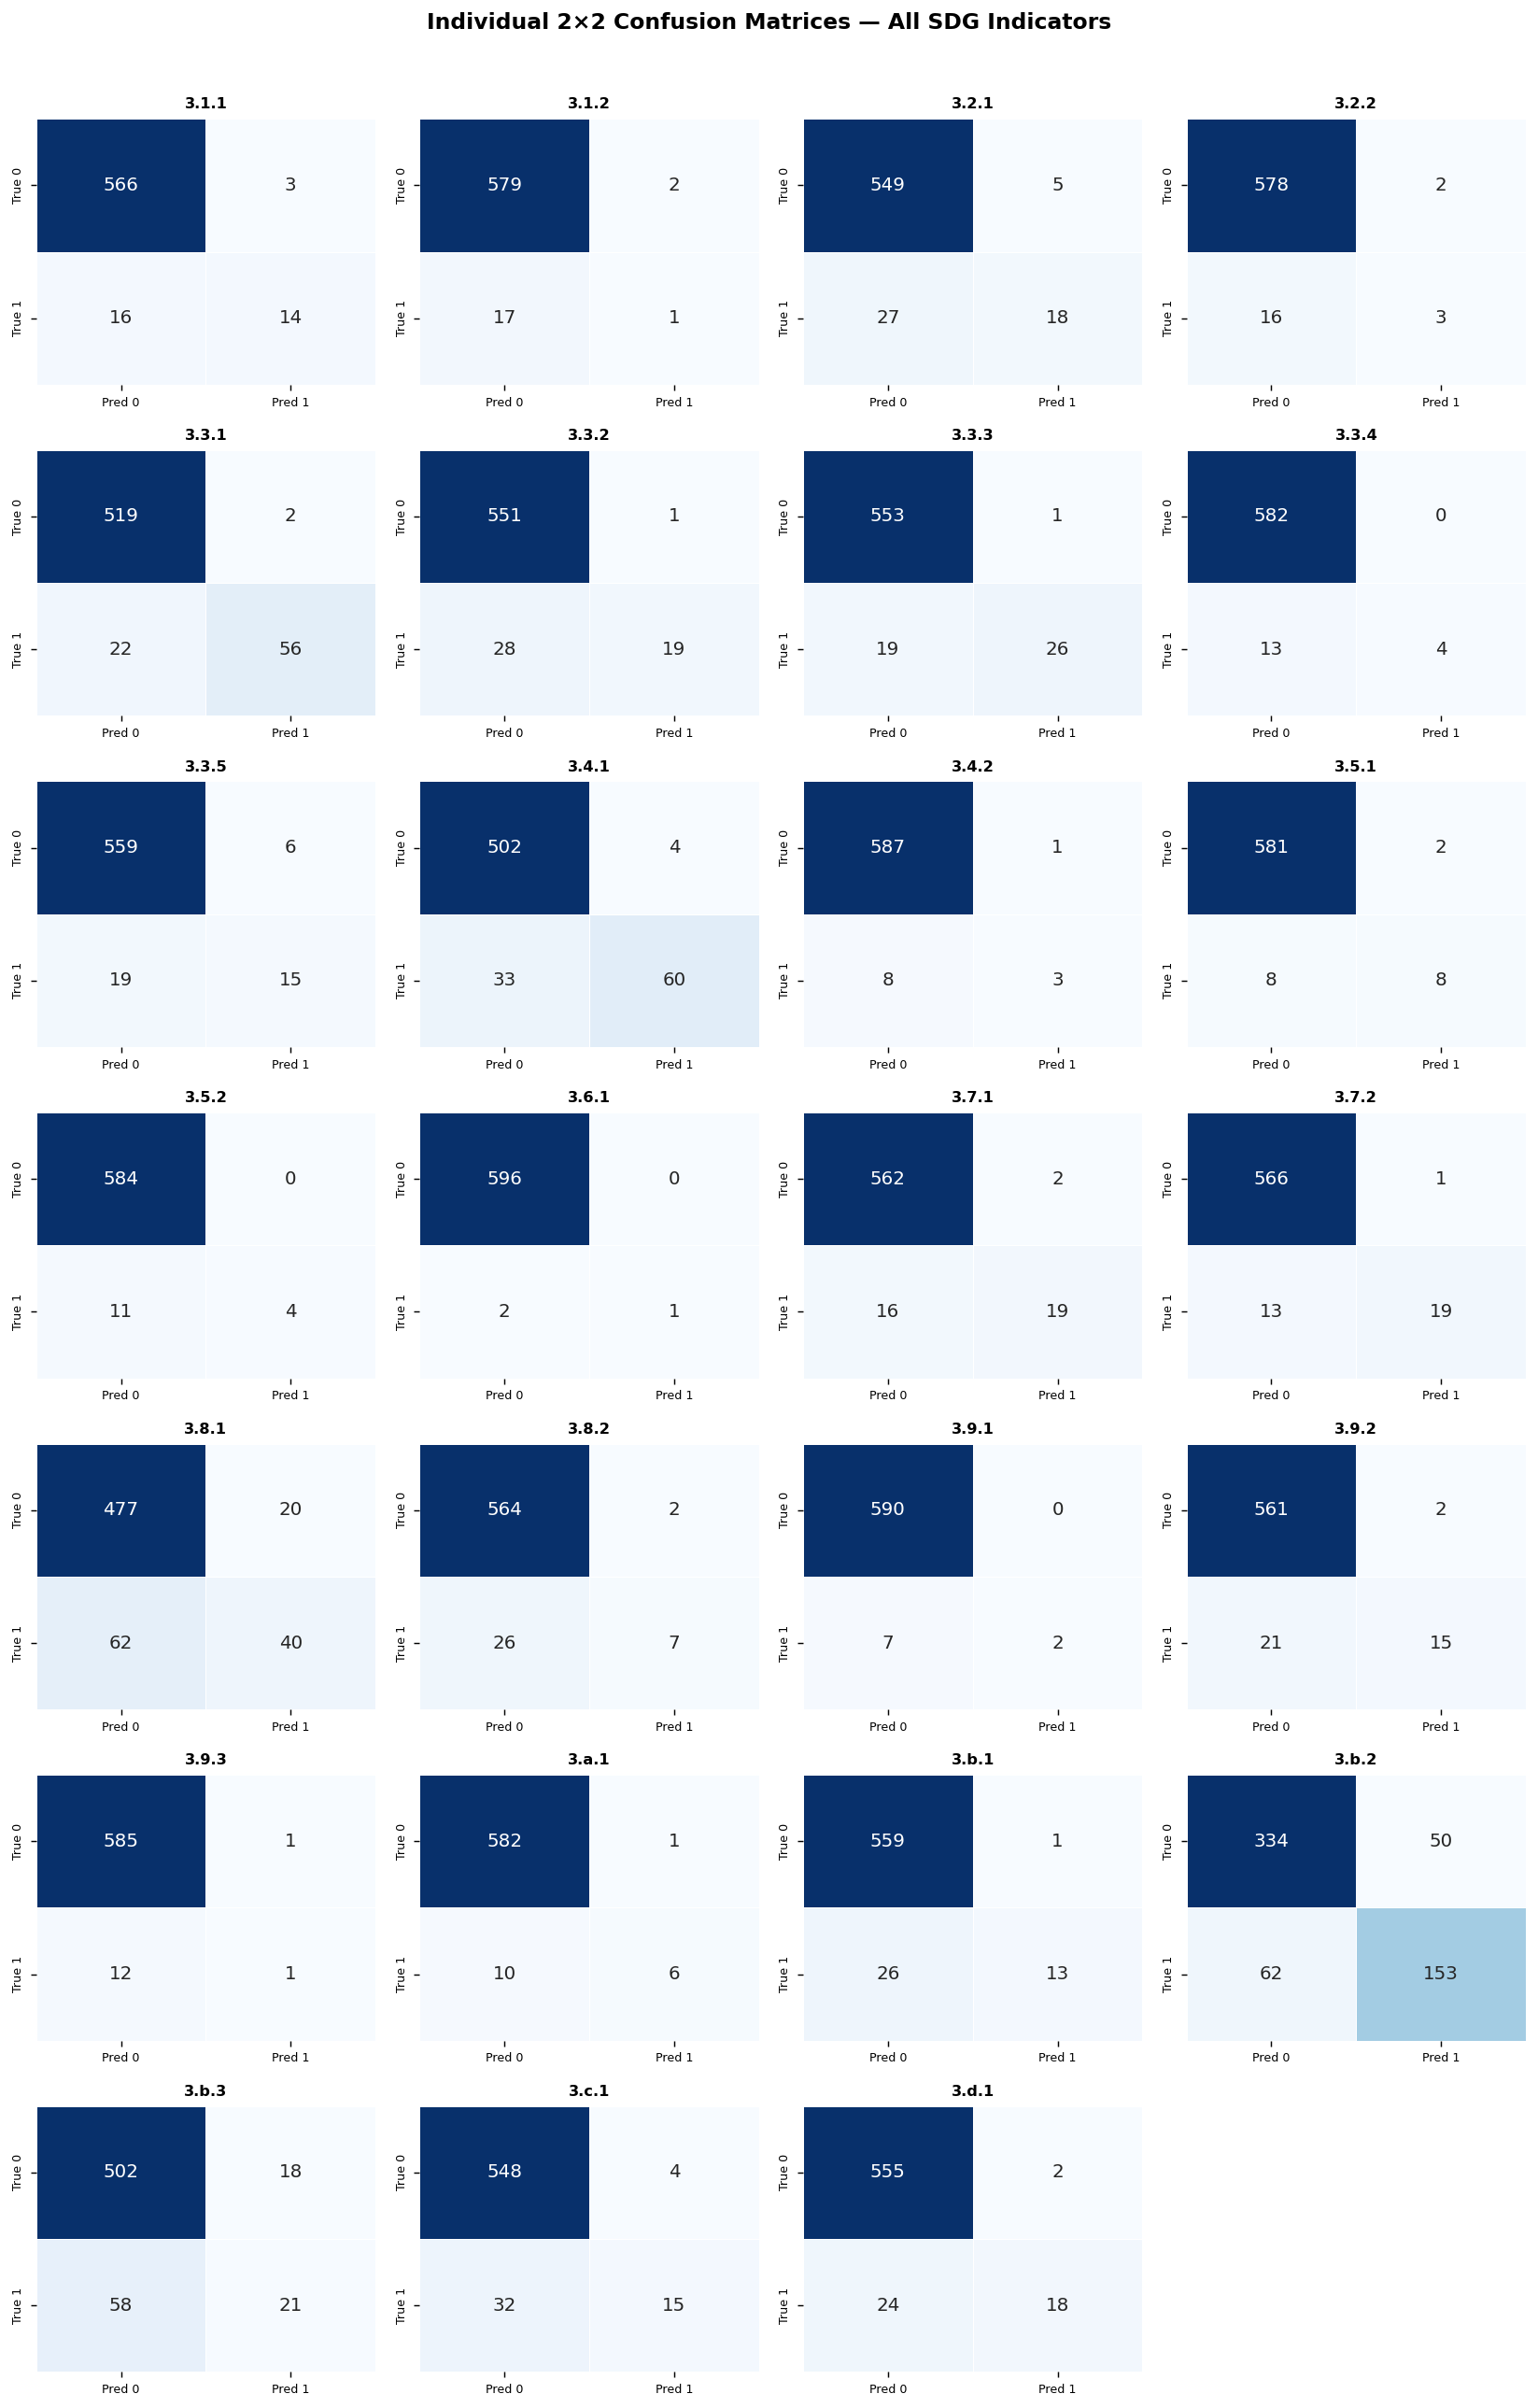

Saved: confusion_matrices_all_labels.png


In [ ]:
# Individual 2×2 confusion matrices
n_labels = len(label_columns)
n_cols = min(4, n_labels)
n_rows = int(np.ceil(n_labels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.2, n_rows*2.8))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, (lbl, cm) in enumerate(zip(label_columns, mcm)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                linewidths=0.5, cbar=False)
    axes[i].set_title(lbl, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Individual 2×2 Confusion Matrices — All SDG Indicators',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/confusion_matrices_all_labels.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_all_labels.png")


## Learning Curves

Computing learning curves (~3 min)...


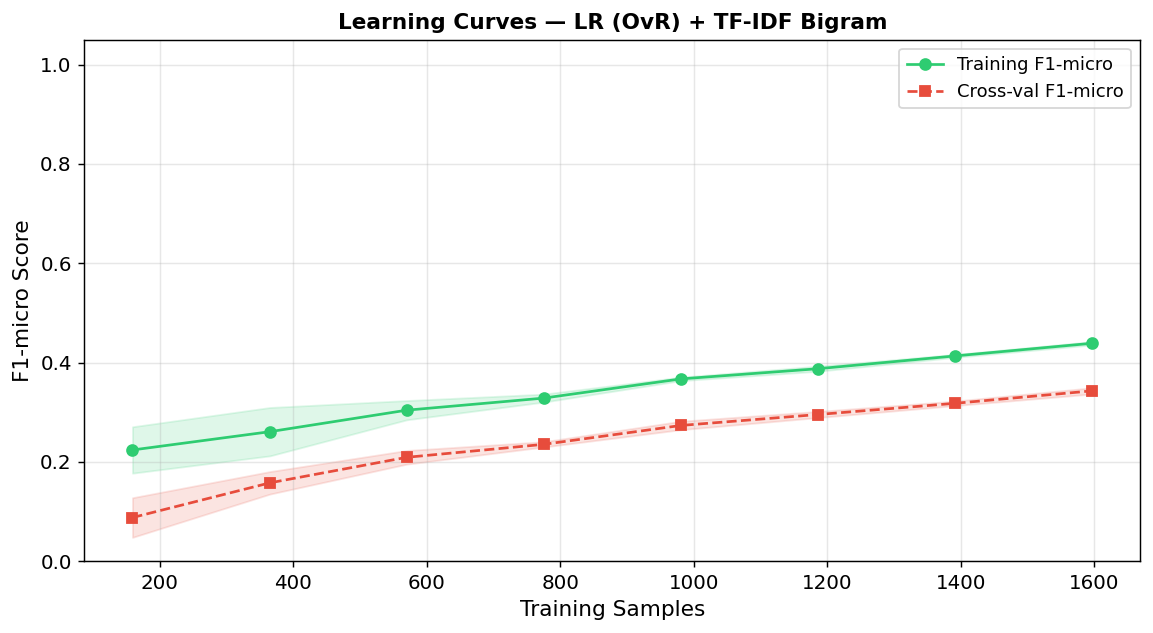

Saved: learning_curves.png

Learning curve summary:


,Training Samples,Train F1-micro,Val F1-micro,Val Std
0,159,0.2239,0.0878,0.0399
1,365,0.2607,0.1577,0.0227
2,570,0.3040,0.2091,0.0138
3,775,0.3283,0.2351,0.0053
4,981,0.3670,0.2733,0.0085
5,1186,0.3874,0.2953,0.0062
6,1391,0.4132,0.3177,0.0046
7,1597,0.4388,0.3429,0.0063


In [ ]:
print("Computing learning curves (~3 min)...")
lc_model = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED)
)
train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='f1_micro', n_jobs=-1,
    shuffle=True, random_state=RANDOM_SEED
)

tr_mean = train_scores.mean(axis=1); tr_std = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1);   va_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_abs, tr_mean, 'o-', color='#2ecc71', label='Training F1-micro')
ax.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='#2ecc71')
ax.plot(train_sizes_abs, va_mean, 's--', color='#e74c3c', label='Cross-val F1-micro')
ax.fill_between(train_sizes_abs, va_mean - va_std, va_mean + va_std,
                alpha=0.15, color='#e74c3c')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('F1-micro Score', fontsize=12)
ax.set_title('Learning Curves — LR (OvR) + TF-IDF Bigram', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

lc_summary = pd.DataFrame({'Training Samples': train_sizes_abs,
                            'Train F1-micro': tr_mean.round(4),
                            'Val F1-micro': va_mean.round(4),
                            'Val Std': va_std.round(4)})
print("\nLearning curve summary:")
display(lc_summary)


## Threshold Tuning — Final Optimal Threshold for Test Predictions

In [ ]:
# Re-run calibrated SVM and confirm optimal threshold
print("Calibrating SVM (Platt scaling, cv=3)...")
svm_base = LinearSVC(random_state=RANDOM_SEED, max_iter=2000, dual='auto')
cal_svm  = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')
ovr_cal  = OneVsRestClassifier(cal_svm)
ovr_cal.fit(X_train, y_train)
y_proba  = ovr_cal.predict_proba(X_val)

thresholds = np.arange(0.10, 0.65, 0.05)
hl_all = [hamming_loss(y_val, (y_proba >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmin(hl_all))])
print(f"\nConfirmed best threshold: {best_t:.2f}  (Hamming Loss: {min(hl_all):.4f})")
print(f"Default t=0.50          : (Hamming Loss: {hl_all[int(np.argmin(np.abs(thresholds-0.5)))]:.4f})")
BEST_THRESH = best_t


Calibrating SVM (Platt scaling, cv=3)...

Confirmed best threshold: 0.40  (Hamming Loss: 0.0434)
Default t=0.50          : (Hamming Loss: 0.0445)


## Ethical Considerations & Bias Analysis

ETHICAL CONSIDERATIONS & BIAS ANALYSIS

1. Label Imbalance & Predictive Equity
---------------------------------------------
   Correlation (support, F1): 0.452
   Positive correlation confirms model is biased toward high-frequency indicators.
   Rare SDG indicators (low support) receive lower F1 — potential equity concern.
   Avg F1 on low-support labels  (<median): 0.411
   Avg F1 on high-support labels (≥median): 0.593

2. Dataset Limitations
---------------------------------------------
   - ~3,000 samples is small for 13+ labels; rare indicators may be severely under-trained.
   - Text sources (tenders, reports, news) may carry Western/donor perspective bias,
     potentially under-representing local/community-based health initiatives.
   - Annotation quality of multi-label assignments was not externally validated.

3. Deployment Risks
---------------------------------------------
   - Misclassification of SDG indicators could misdirect humanitarian funding.
   - False negatives o

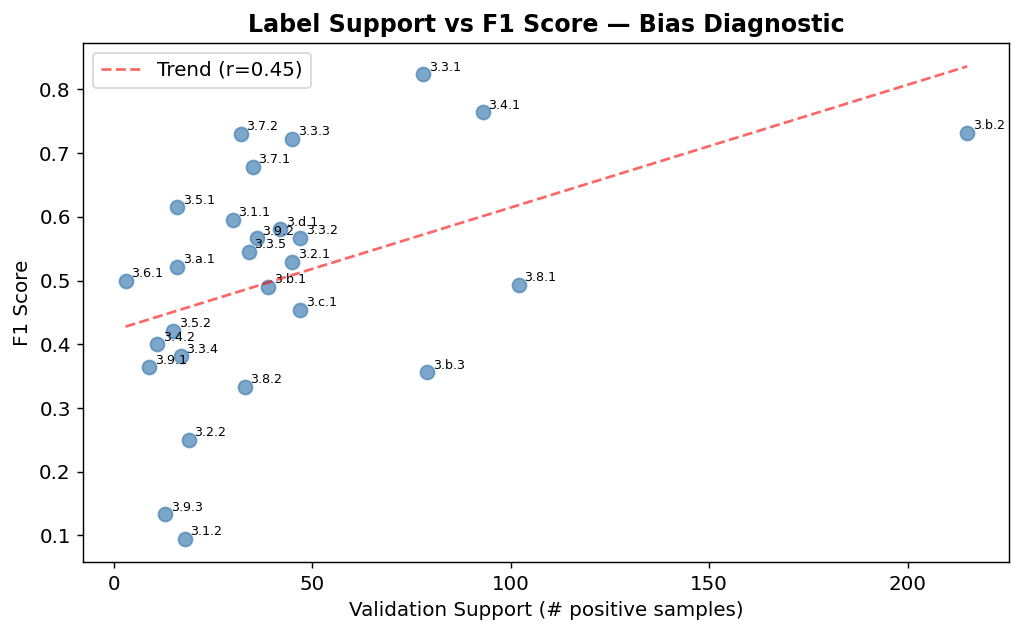

Saved: support_vs_f1_bias.png


In [ ]:
print("=" * 65)
print("ETHICAL CONSIDERATIONS & BIAS ANALYSIS")
print("=" * 65)

# Per-indicator performance gap (proxy for bias toward high-support labels)
print("\n1. Label Imbalance & Predictive Equity")
print("-" * 45)
per_label['Support_pct'] = per_label['Support'] / per_label['Support'].sum() * 100
correlation_support_f1 = per_label[['Support', 'F1']].corr().iloc[0, 1]
print(f"   Correlation (support, F1): {correlation_support_f1:.3f}")
print("   Positive correlation confirms model is biased toward high-frequency indicators.")
print("   Rare SDG indicators (low support) receive lower F1 — potential equity concern.")

low_support = per_label[per_label['Support'] < per_label['Support'].median()].copy()
high_support = per_label[per_label['Support'] >= per_label['Support'].median()].copy()
print(f"   Avg F1 on low-support labels  (<median): {low_support['F1'].mean():.3f}")
print(f"   Avg F1 on high-support labels (≥median): {high_support['F1'].mean():.3f}")

print("\n2. Dataset Limitations")
print("-" * 45)
print("   - ~3,000 samples is small for 13+ labels; rare indicators may be severely under-trained.")
print("   - Text sources (tenders, reports, news) may carry Western/donor perspective bias,")
print("     potentially under-representing local/community-based health initiatives.")
print("   - Annotation quality of multi-label assignments was not externally validated.")

print("\n3. Deployment Risks")
print("-" * 45)
print("   - Misclassification of SDG indicators could misdirect humanitarian funding.")
print("   - False negatives on rare indicators (e.g. neglected diseases) have higher real-world cost.")
print("   - Model should not be used as the sole classification mechanism — human review recommended.")

print("\n4. Responsible Use Recommendations")
print("-" * 45)
print("   - Retrain with larger, more balanced datasets before production deployment.")
print("   - Apply threshold calibration (Exp 12) to maximise recall on rare indicators.")
print("   - Monitor per-label performance longitudinally to detect distributional shift.")

# Plot: support vs F1 scatter
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(per_label['Support'], per_label['F1'], alpha=0.7, s=60, color='steelblue')
for _, row in per_label.iterrows():
    ax.annotate(row['Indicator'], (row['Support'], row['F1']),
                fontsize=7, xytext=(3,2), textcoords='offset points')
ax.set_xlabel('Validation Support (# positive samples)')
ax.set_ylabel('F1 Score')
ax.set_title('Label Support vs F1 Score — Bias Diagnostic', fontweight='bold')
z = np.polyfit(per_label['Support'], per_label['F1'], 1)
p = np.poly1d(z)
ax.plot(sorted(per_label['Support']), p(sorted(per_label['Support'])),
        'r--', alpha=0.6, label=f'Trend (r={correlation_support_f1:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/support_vs_f1_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: support_vs_f1_bias.png")


## Final Test Predictions

In [ ]:
# Predict on test set using calibrated SVM + optimal threshold
print("Generating final test predictions...")

# Use calibrated model for probability-based threshold application
y_test_proba = ovr_cal.predict_proba(X_test)
y_test_pred  = (y_test_proba >= BEST_THRESH).astype(int)

print(f"Test predictions shape : {y_test_pred.shape}")
print(f"Applied threshold      : {BEST_THRESH:.2f}")
print(f"Avg predicted labels/doc: {y_test_pred.sum(axis=1).mean():.2f}")

# Build submission DataFrame
test_pred_df = test_ids.copy()
for i, col in enumerate(label_columns):
    test_pred_df[col] = y_test_pred[:, i]

test_pred_df.to_csv(PROJECT_FOLDER + 'outputs/test_predictions.csv', index=False)
print(f"\n Saved: outputs/test_predictions.csv ({len(test_pred_df)} rows × {len(label_columns)} labels)")
display(test_pred_df.head())


Generating final test predictions...
Test predictions shape : (998, 27)
Applied threshold      : 0.40
Avg predicted labels/doc: 1.42

 Saved: outputs/test_predictions.csv (998 rows × 27 labels)


,Unique ID,3.1.1,3.1.2,3.2.1,3.2.2,3.3.1,3.3.2,3.3.3,3.3.4,3.3.5,...,3.8.2,3.9.1,3.9.2,3.9.3,3.a.1,3.b.1,3.b.2,3.b.3,3.c.1,3.d.1
0,49848,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,52348,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,103541,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,52382,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,47212,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0


## Summary

In [ ]:
print("=" * 70)
print("FINAL SUMMARY — SDG 3 Indicator Text Classification")
print("=" * 70)
print(f"  Dataset             : ~3,000 training samples")
print(f"  Number of labels    : {len(label_columns)} SDG 3 indicators")
print(f"  Best model          : Linear SVM + TF-IDF Bigram (OvR)")
print(f"  Best Hamming Loss   : {hl:.4f}")
print(f"  F1-micro            : {f1m:.4f}")
print(f"  F1-macro            : {f1M:.4f}")
print(f"  Exact Match Ratio   : {exact:.4f}")
print(f"  Optimal threshold   : {BEST_THRESH:.2f}")
print()
print("  Experiments run: 12 (Notebooks 2 & 3)")
print("  Key findings:")
print("    1. Linear SVM outperforms LR and Random Forest on sparse TF-IDF vectors.")
print("    2. Bigram TF-IDF (10k vocab) is the best single feature representation.")
print("    3. In-corpus Word2Vec and pre-trained GloVe underperform TF-IDF,")
print("       suggesting domain-specific embeddings (BioBERT) as future work.")
print("    4. Threshold tuning provides a free post-processing gain on rare labels.")
print("    5. Class-balanced LR improves rare-label recall but may hurt overall HL.")
print()
print(" Notebook 4 complete. All outputs saved to Google Drive.")


FINAL SUMMARY — SDG 3 Indicator Text Classification
  Dataset             : ~3,000 training samples
  Number of labels    : 27 SDG 3 indicators
  Best model          : Linear SVM + TF-IDF Bigram (OvR)
  Best Hamming Loss   : 0.0458
  F1-micro            : 0.6023
  F1-macro            : 0.5054
  Exact Match Ratio   : 0.3589
  Optimal threshold   : 0.40

  Experiments run: 12 (Notebooks 2 & 3)
  Key findings:
    1. Linear SVM outperforms LR and Random Forest on sparse TF-IDF vectors.
    2. Bigram TF-IDF (10k vocab) is the best single feature representation.
    3. In-corpus Word2Vec and pre-trained GloVe underperform TF-IDF,
       suggesting domain-specific embeddings (BioBERT) as future work.
    4. Threshold tuning provides a free post-processing gain on rare labels.
    5. Class-balanced LR improves rare-label recall but may hurt overall HL.

 Notebook 4 complete. All outputs saved to Google Drive.
